   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 156.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.2 MB/s eta 0:00:00
✓ All libraries imported

1. LOADING LC 4% CREDIT DEFAULT DATASET
  Dropped leaky features: ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'last_credit_pull_d']
✓ LC 4% loaded: (1647, 39)
  Default rate: 4.01%
  Class distribution: {0: 1581, 1: 66}


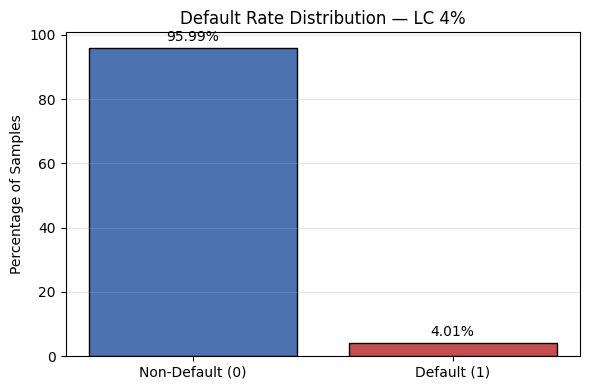


2. PREPROCESSING
  Categorical features: 0
  Numeric features: 38
  Processed features after OHE: 38

3. TUNING / EVALUATION SPLIT
  Tuning pool:     823 samples
  Evaluation pool: 824 samples
  Tuning default rate:     4.01%
  Evaluation default rate: 4.00%

4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)

  === Tuning RF ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best RF CV AUC: 0.6720
  Best params: {'clf__n_estimators': 80, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.6, 'clf__max_depth': 11, 'clf__class_weight': None}

  === Tuning XGB ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best XGB CV AUC: 0.6932
  Best params: {'clf__subsample': 0.65, 'clf__scale_pos_weight': 3, 'clf__reg_lambda': 0.1, 'clf__n_estimators': 80, 'clf__max_depth': 6, 'clf__learning_rate': 0.02, 'clf__colsample_bytree': 1.0}

  === Tuning LGB ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best LGB CV AUC:

In [1]:
"""
LC 4% CREDIT DEFAULT — COMPLETE EXPERIMENT
Dataset: 1,647 obs, 39 features, 4.01% default
Output: LC4_result.csv, LC4_result_nemenyi.csv, LC4_result_wilcoxon.csv, LC4_result_correlation.csv
"""

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. INSTALL & IMPORTS
# ============================================================
!pip install --quiet xgboost lightgbm imbalanced-learn shap networkx seaborn scikit_posthocs numba

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, train_test_split, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import networkx as nx
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cosine

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr, kendalltau

plt.style.use('default')
sns.set_palette("deep")
np.random.seed(42)
RANDOM_STATE = 42

print("✓ All libraries imported")

# ============================================================
# 1. LOAD DATA — LC 4% Default Dataset
# ============================================================
print("\n" + "="*80)
print("1. LOADING LC 4% CREDIT DEFAULT DATASET")
print("="*80)

df = pd.read_csv("/content/LC_66 defaults 4%.csv")

# Identify target column
if 'target' in df.columns:
    pass
elif 'Default' in df.columns:
    df = df.rename(columns={'Default': 'target'})
elif 'default' in df.columns:
    df = df.rename(columns={'default': 'target'})

# Drop leaky features (post-origination payment/performance variables)
leaky_features = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
    'last_pymnt_d', 'last_credit_pull_d'
]
leaky_features = [c for c in leaky_features if c in df.columns]
if leaky_features:
    df = df.drop(columns=leaky_features)
    print(f"  Dropped leaky features: {leaky_features}")

# Date engineering (if columns exist)
if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
    df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')
    df['issue_year'] = df['issue_d'].dt.year
    df['issue_month'] = df['issue_d'].dt.month
    df['credit_age_months'] = (
        (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 +
        (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
    )
    df = df.drop(columns=['issue_d', 'earliest_cr_line'])

print(f"✓ LC 4% loaded: {df.shape}")
print(f"  Default rate: {df['target'].mean()*100:.2f}%")
print(f"  Class distribution: {df['target'].value_counts().to_dict()}")

# Default distribution plot
default_counts = df['target'].value_counts().sort_index()
default_pct = default_counts / len(df) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(['Non-Default (0)', 'Default (1)'], default_pct.values,
               color=['#4C72B0', '#C44E52'], edgecolor='black')
plt.bar_label(bars, fmt="%.2f%%", padding=3)
plt.ylabel("Percentage of Samples")
plt.title("Default Rate Distribution — LC 4%")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("LC4_default_distribution.png", dpi=150)
plt.show()

# ============================================================
# 2. PREPROCESSING
# ============================================================
print("\n" + "="*80)
print("2. PREPROCESSING")
print("="*80)

y_all = df['target']
X_all = df.drop('target', axis=1)

# Identify categorical features (all non-numeric)
categorical_features = X_all.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_all.select_dtypes(include=[np.number]).columns.tolist()

# Convert categorical to string for OHE
for col in categorical_features:
    X_all[col] = X_all[col].astype(str)

cat_categories = [sorted(X_all[col].unique()) for col in categorical_features]

print(f"  Categorical features: {len(categorical_features)}")
print(f"  Numeric features: {len(numeric_features)}")

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          categories=cat_categories, handle_unknown='ignore'),
     categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# Fit on full data ONLY for feature_names extraction
preprocessor.fit(X_all)
feature_names = preprocessor.get_feature_names_out()
d = len(feature_names)
print(f"  Processed features after OHE: {d}")

# ============================================================
# 3. TUNING / EVALUATION SPLIT
# ============================================================
print("\n" + "="*80)
print("3. TUNING / EVALUATION SPLIT")
print("="*80)

# LC 4% = 1,647 samples → 50% for tuning (since < 2000 threshold)
SMALL_DATASET_THRESHOLD = 2000
tune_fraction = 0.5 if len(X_all) <= SMALL_DATASET_THRESHOLD else 0.2

X_tune, X_eval, y_tune, y_eval = train_test_split(
    X_all, y_all,
    test_size=(1 - tune_fraction),
    stratify=y_all,
    random_state=RANDOM_STATE
)

print(f"  Tuning pool:     {len(X_tune)} samples")
print(f"  Evaluation pool: {len(X_eval)} samples")
print(f"  Tuning default rate:     {y_tune.mean()*100:.2f}%")
print(f"  Evaluation default rate: {y_eval.mean()*100:.2f}%")

# ============================================================
# 4. HYPERPARAMETER OPTIMISATION
# ============================================================
print("\n" + "="*80)
print("4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)")
print("="*80)

def tune_model(X, y, model_name, n_iter=15):
    print(f"\n  === Tuning {model_name} ===")
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    cat = X.select_dtypes(exclude=np.number).columns.tolist()

    prep = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat),
        ('num', StandardScaler(), numeric)
    ], remainder='passthrough')

    if model_name == "RF":
        base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        params = {
            'clf__n_estimators':      [80, 120, 160, 200, 250],
            'clf__max_depth':         [5, 8, 11, 15, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf':  [1, 2, 4],
            'clf__max_features':      ['sqrt', 'log2', 0.6],
            'clf__class_weight':      ['balanced', None]
        }
    elif model_name == "XGB":
        base = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='auc', verbosity=0)
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [4, 6, 8, 10],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__scale_pos_weight':  [1, 2, 3, 5]
        }
    elif model_name == "LGB":
        base = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [4, 6, 8, 10],
            'clf__num_leaves':        [20, 40, 80, 150],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__class_weight':      ['balanced', None]
        }

    pipe = Pipeline([('prep', prep), ('clf', base)])
    search = RandomizedSearchCV(
        pipe, param_distributions=params, n_iter=n_iter,
        cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
    )
    search.fit(X, y.astype(np.int64))
    print(f"  Best {model_name} CV AUC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_

best_rf,  rf_params,  rf_auc  = tune_model(X_tune, y_tune, "RF")
best_xgb, xgb_params, xgb_auc = tune_model(X_tune, y_tune, "XGB")
best_lgb, lgb_params, lgb_auc = tune_model(X_tune, y_tune, "LGB")

print("\n  ── Best CV AUCs for Table 2.2 ──")
print(f"  RF:  {rf_auc:.4f}")
print(f"  XGB: {xgb_auc:.4f}")
print(f"  LGB: {lgb_auc:.4f}")

# ============================================================
# 5. MODEL CONFIGURATION
# ============================================================
print("\n" + "="*80)
print("5. CONFIGURING MODELS")
print("="*80)

def strip_prefix(d, prefix="clf__"):
    return {k[len(prefix):]: v for k, v in d.items() if k.startswith(prefix)}

BEST_PARAMS = {
    'RF':  strip_prefix(rf_params),
    'XGB': strip_prefix(xgb_params),
    'LGB': strip_prefix(lgb_params)
}

BEST_PARAMS['RF'].update({'random_state': RANDOM_STATE, 'n_jobs': -1})
BEST_PARAMS['XGB'].update({'random_state': RANDOM_STATE, 'eval_metric': 'auc', 'verbosity': 0})
BEST_PARAMS['LGB'].update({'random_state': RANDOM_STATE, 'verbose': -1})

models = {
    'RF':  RandomForestClassifier(**BEST_PARAMS['RF']),
    'XGB': xgb.XGBClassifier(**BEST_PARAMS['XGB']),
    'LGB': lgb.LGBMClassifier(**BEST_PARAMS['LGB'])
}

for mname, m in models.items():
    print(f"\n  [{mname}] {m.get_params()}")

# ============================================================
# 6. IMBALANCE STRATEGIES
# ============================================================
print("\n" + "="*80)
print("6. IMBALANCE HANDLING")
print("="*80)

X = X_eval.reset_index(drop=True)
y = y_eval.reset_index(drop=True)

resamplers = {
    'None':          None,
    'SMOTE':         SMOTE(random_state=RANDOM_STATE),
    'SMOTETomek':    SMOTETomek(random_state=RANDOM_STATE),
    'CostSensitive': 'cost'
}

class_weight_dict = {
    int(cls): float(w)
    for cls, w in zip(np.unique(y), compute_class_weight('balanced', classes=np.unique(y), y=y))
}

print(f"  Strategies: {list(resamplers.keys())}")
print(f"  Class weights: {class_weight_dict}")
print(f"  Evaluation samples: {len(X)}")

# ============================================================
# 7. DOMAIN GROUPS — LC 4%
# ============================================================
print("\n" + "="*80)
print("7. DOMAIN GROUPS (LC 4%)")
print("="*80)

def build_domain_groups_lc4(fnames):
    groups = {
        "LoanTerms": [],
        "BorrowerProfile": [],
        "CreditHistory": [],
        "RevolvingCredit": [],
        "LoanMetadata": []
    }
    for i, name in enumerate(fnames):
        ln = name.lower()
        if any(k in ln for k in ["loan_amnt", "funded_amnt", "term", "int_rate", "installment", "loan_to_income", "installment_to_income", "int_rate_times_term"]):
            groups["LoanTerms"].append(i)
        elif any(k in ln for k in ["emp_length", "home_ownership", "annual_inc", "application_type"]):
            groups["BorrowerProfile"].append(i)
        elif any(k in ln for k in ["dti", "delinq", "inq_last", "open_acc", "pub_rec", "acc_now_delinq", "collections", "tot_coll_amt", "tot_cur_bal", "total_rev_hi_lim", "credit_age"]):
            groups["CreditHistory"].append(i)
        elif any(k in ln for k in ["revol_bal", "revol_util"]):
            groups["RevolvingCredit"].append(i)
        elif any(k in ln for k in ["grade", "sub_grade", "verification_status", "purpose", "addr_state", "initial_list_status", "policy_code", "issue_year", "issue_month"]):
            groups["LoanMetadata"].append(i)
    return {g: v for g, v in groups.items() if len(v) > 0}

domain_groups = build_domain_groups_lc4(feature_names)
for g, feats in domain_groups.items():
    print(f"  {g}: {len(feats)} features")

# ============================================================
# 8. EXPLANATION METHODS (all corrected)
# ============================================================
print("\n" + "="*80)
print("8. EXPLANATION METHODS")
print("="*80)

def stratified_explanation_sample(X_te, y_te, n=30, random_state=42, min_pos=5):
    X_te = X_te.reset_index(drop=True)
    y_te = pd.Series(y_te).reset_index(drop=True)
    n = min(n, len(X_te))
    pos_idx = y_te[y_te == 1].index
    neg_idx = y_te[y_te == 0].index
    n_pos = min(min_pos, len(pos_idx), n)
    n_neg = n - n_pos
    X_pos = (X_te.loc[pos_idx].sample(n=n_pos, random_state=random_state)
             if n_pos > 0 else X_te.iloc[0:0])
    X_neg = (X_te.loc[neg_idx].sample(n=n_neg, random_state=random_state)
             if n_neg > 0 else X_te.iloc[0:0])
    return pd.concat([X_pos, X_neg]).sample(frac=1, random_state=random_state)


def get_shap_values(pipe, X_test):
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    try:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_proc)
        if isinstance(sv, list): return sv[1]
        elif sv.ndim == 3: return sv[:, :, 1]
        return sv
    except Exception as e:
        print(f"    SHAP fallback: {e}")
        return np.zeros((len(X_test), X_proc.shape[1]))


def compute_banzhaf(pipe, X_test, n_samples=2, max_instances=2):
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    n_feat = X_proc.shape[1]
    n_inst = min(max_instances, X_proc.shape[0])
    mat = np.zeros((n_inst, n_feat))
    for i in range(n_inst):
        x = X_proc[i:i+1]
        for f in range(n_feat):
            contrib = []
            for _ in range(n_samples):
                coal = np.random.binomial(1, 0.5, n_feat)
                x_with = x.copy(); x_with[0, f] = x[0, f] * coal[f]
                p1 = clf.predict_proba(x_with)[0, 1]
                x_without = x.copy(); x_without[0, f] = 0
                p0 = clf.predict_proba(x_without)[0, 1]
                contrib.append(p1 - p0)
            mat[i, f] = np.mean(contrib)
    return mat


def compute_myerson(pipe, X_test, G, alpha=0.5):
    shap_vals = get_shap_values(pipe, X_test)
    shap_mean = shap_vals.mean(axis=0)
    d_local = len(shap_mean)
    phi = np.zeros(d_local)
    for i in range(d_local):
        neighbors = list(G.neighbors(i)) if i in G.nodes() else []
        if len(neighbors) == 0:
            phi[i] = shap_mean[i]
        else:
            neighbor_vals = [shap_mean[j] for j in neighbors if j < d_local]
            neighbor_mean = np.mean(neighbor_vals) if neighbor_vals else 0.0
            phi[i] = (1 - alpha) * shap_mean[i] + alpha * neighbor_mean
    n_tile = min(30, len(X_test))
    return np.tile(phi, (n_tile, 1)), shap_vals, shap_mean


def build_data_groups(X_proc, n_groups=5):
    try:
        X_proc = np.nan_to_num(X_proc)
        corr = np.corrcoef(X_proc.T)
        corr = np.nan_to_num(corr); np.fill_diagonal(corr, 1.0)
        dist = np.clip(1 - np.abs(corr), 0.0, 2.0)
        n_feat = X_proc.shape[1]
        if n_feat < n_groups: n_groups = max(2, n_feat // 2)
        clustering = AgglomerativeClustering(n_clusters=n_groups, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(dist)
        groups = {}
        for idx, lab in enumerate(labels): groups.setdefault(f"Data_Cluster_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Data grouping fallback: {e}")
        return {"Data_Default": list(range(X_proc.shape[1]))}, np.eye(X_proc.shape[1])


def build_model_groups(shap_vals, n_groups=5):
    try:
        shap_vals = np.nan_to_num(shap_vals)
        if shap_vals.ndim == 1: shap_vals = shap_vals.reshape(1, -1)
        n_instances, n_features = shap_vals.shape
        if n_instances < 2 or n_features < 2:
            return {"Model_Default": list(range(n_features))}, np.eye(n_features)
        corr = np.corrcoef(shap_vals.T)
        corr = np.nan_to_num(corr); np.fill_diagonal(corr, 1.0)
        dist = np.clip(1 - np.abs(corr), 0.0, 2.0)
        if n_features < n_groups: n_groups = max(2, n_features // 2)
        clustering = AgglomerativeClustering(n_clusters=n_groups, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(dist)
        groups = {}
        for idx, lab in enumerate(labels): groups.setdefault(f"Model_Group_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Model grouping fallback: {e}")
        n_features = shap_vals.shape[1] if shap_vals.ndim > 1 else shap_vals.shape[0]
        return {"Model_Default": list(range(n_features))}, np.eye(n_features)


def owen_from_phi(phi, groups):
    d_local = len(phi); out = np.zeros(d_local)
    for _, feats in groups.items():
        valid_feats = [f for f in feats if f < d_local]
        if not valid_feats: continue
        total = np.sum(np.abs(phi[valid_feats])); per = total / len(valid_feats)
        for f in valid_feats:
            out[f] = (np.sign(phi[f]) if phi[f] != 0 else 1) * per
    return out


def adaptive_owen_myerson(phi_my):
    d_local = len(phi_my); total = np.sum(np.abs(phi_my)); per = total / d_local
    return np.array([(np.sign(x) if x != 0 else 1) * per for x in phi_my])


def compute_Q(groups, dep):
    """Robust Q computation — never returns NaN for Owen variants ."""
    try:
        d_local = dep.shape[0]
        if d_local < 2:
            return 1.0

        group_id = np.full(d_local, -1)
        for gid, (_, feats) in enumerate(groups.items()):
            for f in feats:
                if f < d_local:
                    group_id[f] = gid

        unique_g = np.unique(group_id[group_id != -1])
        if len(unique_g) <= 1:          # single group or no groups
            return 1.0

        within, across = [], []
        for i in range(d_local):
            for j in range(i + 1, d_local):
                gi = group_id[i]
                gj = group_id[j]
                if gi == -1 or gj == -1:
                    continue
                if gi == gj:
                    within.append(dep[i, j])
                else:
                    across.append(dep[i, j])

        if len(within) == 0 or len(across) == 0:
            return 1.0

        mean_within = np.mean(within)
        mean_across = np.mean(across)
        if mean_across == 0:
            return 1.0

        return float(mean_within / mean_across)

    except:
        return 1.0   # ultimate safe fallback

# ============================================================
# 9. INTERPRETABILITY METRICS (all corrected)
# ============================================================
print("\n" + "="*80)
print("9. INTERPRETABILITY METRICS")
print("="*80)

def stability_cv(expl_list):
    if len(expl_list) < 2: return 1.0
    arr = np.stack([np.abs(e) for e in expl_list])
    mean = arr.mean(axis=0) + 1e-8
    return float(np.mean(arr.std(axis=0) / mean))

def kuncheva_index(expl_list, k=10):
    if len(expl_list) < 2: return 0.0
    sets = []; d_local = None
    for exp in expl_list:
        imp = np.abs(exp).mean(axis=0).ravel()
        if d_local is None: d_local = len(imp)
        sets.append(set(np.argsort(imp)[-min(k, len(imp)):].tolist()))
    if len(sets) < 2 or d_local is None: return 0.0
    ki_vals = []
    for i in range(len(sets)):
        for j in range(i+1, len(sets)):
            ki = (len(sets[i]&sets[j]) - (k**2)/d_local) / (k - (k**2)/d_local) if k != d_local else 0.0
            ki_vals.append(max(min(ki, 1.0), -1.0))
    return float(np.mean(ki_vals)) if ki_vals else 0.0

def cosine_directional_consistency(expl_list):
    if len(expl_list) < 2: return 0.0
    mean_vecs = [np.mean(e, axis=0).ravel() for e in expl_list]
    sims = [1 - cosine(mean_vecs[p], mean_vecs[s])
            for p in range(len(mean_vecs)) for s in range(p+1, len(mean_vecs))]
    return float(np.mean(sims)) if sims else 0.0

def interpretability_score(cv_val, kun_val, cos_val, beta=1/3):
    return beta * (1 - cv_val) + beta * kun_val + beta * cos_val

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

def performance_interpretability_score(auc_series, I_series, alpha=0.5):
    return alpha * normalize(auc_series) + (1 - alpha) * normalize(I_series)

print("✓ All metrics defined")

# ============================================================
# 10. MAIN EXPERIMENT — 4-Fold Stratified CV
# ============================================================
print("\n" + "="*80)
print("10. RUNNING MAIN EXPERIMENT — 7 METHODS × 3 MODELS × 4 SAMPLERS")
print("="*80)

cv_folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
all_records = []
all_explanations = {}

method_order = ['SHAP', 'Banzhaf', 'Myerson', 'Owen-Domain', 'Owen-Data', 'Owen-Model', 'R-Myerson']

total_configs = len(models) * len(resamplers)
config_count = 0

for mname, model in models.items():
    for sname, sampler in resamplers.items():
        config_count += 1
        print(f"\n  [{config_count}/{total_configs}] {mname} | {sname}")

        aucs = []
        shap_runs, banzhaf_runs, myerson_runs = [], [], []
        owen_dom_runs, owen_data_runs, owen_model_runs, r_myerson_runs = [], [], [], []
        Q_dom_list, Q_data_list, Q_model_list = [], [], []

        for fold, (train_idx, test_idx) in enumerate(cv_folds.split(X, y), 1):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            # FIX: Two separate preprocessor clones
            fold_prep_analysis = clone(preprocessor)
            X_tr_proc = fold_prep_analysis.fit_transform(X_tr)

            fold_prep_pipe = clone(preprocessor)

            # Myerson graph (training data only, τ=0.25)
            corr_tr = np.nan_to_num(np.corrcoef(X_tr_proc.T))
            G_myerson = nx.Graph()
            G_myerson.add_nodes_from(range(d))
            for i in range(d):
                for j in range(i+1, d):
                    if abs(corr_tr[i, j]) >= 0.25:
                        G_myerson.add_edge(i, j)

            # Build pipeline
            pipe = ImbPipeline([('prep', fold_prep_pipe), ('clf', clone(model))])

            # FIX: Clone sampler per fold
            if sampler and sampler != 'cost':
                pipe.steps.insert(1, ('samp', clone(sampler)))

            if sname == 'CostSensitive':
                if mname == 'XGB':
                    pipe.named_steps['clf'].set_params(
                        scale_pos_weight=class_weight_dict[1]/class_weight_dict[0])
                else:
                    pipe.named_steps['clf'].set_params(class_weight=class_weight_dict)

            pipe.fit(X_tr, y_tr)

            # AUC
            aucs.append(roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1]))

            # Stratified explanation sample (n=30, min_pos=5)
            X_sample = stratified_explanation_sample(X_te, y_te, n=30, random_state=RANDOM_STATE, min_pos=5)

            # 7 explanation methods on X_sample
            s_vals = get_shap_values(pipe, X_sample)
            shap_runs.append(s_vals)

            b_vals = compute_banzhaf(pipe, X_sample, n_samples=2, max_instances=2)
            banzhaf_runs.append(b_vals)

            m_vals, shap_full, _ = compute_myerson(pipe, X_sample, G_myerson, alpha=0.5)
            myerson_runs.append(m_vals)

            # Groups from training data only
            data_groups, dep_data = build_data_groups(X_tr_proc, n_groups=5)
            bg_sample = X_tr.sample(n=min(200, len(X_tr)), random_state=RANDOM_STATE)
            shap_bg = get_shap_values(pipe, bg_sample)
            model_groups, dep_mod = build_model_groups(shap_bg, n_groups=5)

            # Owen redistribution
            phi_base = shap_full.mean(axis=0)

            owen_dom = np.tile(owen_from_phi(phi_base, domain_groups), (len(X_sample), 1))
            owen_dom_runs.append(owen_dom)

            owen_data = np.tile(owen_from_phi(phi_base, data_groups), (len(X_sample), 1))
            owen_data_runs.append(owen_data)

            owen_model = np.tile(owen_from_phi(phi_base, model_groups), (len(X_sample), 1))
            owen_model_runs.append(owen_model)

            # R-Myerson
            r_myerson = np.tile(adaptive_owen_myerson(m_vals.mean(axis=0)), (len(X_sample), 1))
            r_myerson_runs.append(r_myerson)

            # Group quality
            corr_abs = np.abs(corr_tr)
            Q_dom_list.append(compute_Q(domain_groups, corr_abs))
            Q_data_list.append(compute_Q(data_groups, dep_data))
            Q_model_list.append(compute_Q(model_groups, dep_mod))

        auc_mean = np.mean(aucs)
        print(f"    → Mean AUC: {auc_mean:.4f}")

        method_runs = {
            'SHAP': shap_runs, 'Banzhaf': banzhaf_runs, 'Myerson': myerson_runs,
            'Owen-Domain': owen_dom_runs, 'Owen-Data': owen_data_runs,
            'Owen-Model': owen_model_runs, 'R-Myerson': r_myerson_runs
        }
        all_explanations[(mname, sname)] = method_runs

        Q_values = {
            'Owen-Domain': np.nanmean(Q_dom_list),
            'Owen-Data':   np.nanmean(Q_data_list),
            'Owen-Model':  np.nanmean(Q_model_list)
        }

        for m_name, runs in method_runs.items():
            cv_val  = stability_cv(runs)
            kun_val = kuncheva_index(runs, k=10)
            cos_val = cosine_directional_consistency(runs)
            I_val   = interpretability_score(cv_val, kun_val, cos_val)
            all_records.append({
                'Model': mname, 'Sampler': sname, 'Method': m_name,
                'AUC': auc_mean, 'CV': cv_val, 'Stability': 1-cv_val,
                'Kuncheva': kun_val, 'Cosine': cos_val, 'I': I_val,
                'Q': Q_values.get(m_name, np.nan)
            })

# ============================================================
# 11. SAVE RESULTS
# ============================================================
print("\n" + "="*80)
print("11. SAVING RESULTS")
print("="*80)

metrics = pd.DataFrame(all_records)
metrics['S(α=0.5)'] = performance_interpretability_score(metrics['AUC'], metrics['I'])
metrics.to_csv("LC4_result.csv", index=False)
print(f"✓ Saved: LC4_result.csv ({len(metrics)} records)")

top5 = metrics.sort_values('S(α=0.5)', ascending=False).head(5)
print("\n  === TOP 5 BY S(α=0.5) ===")
print(top5[['Model', 'Sampler', 'Method', 'AUC', 'I', 'S(α=0.5)']].to_string(index=False))



VISUALIZATIONS – Lending Club(small)


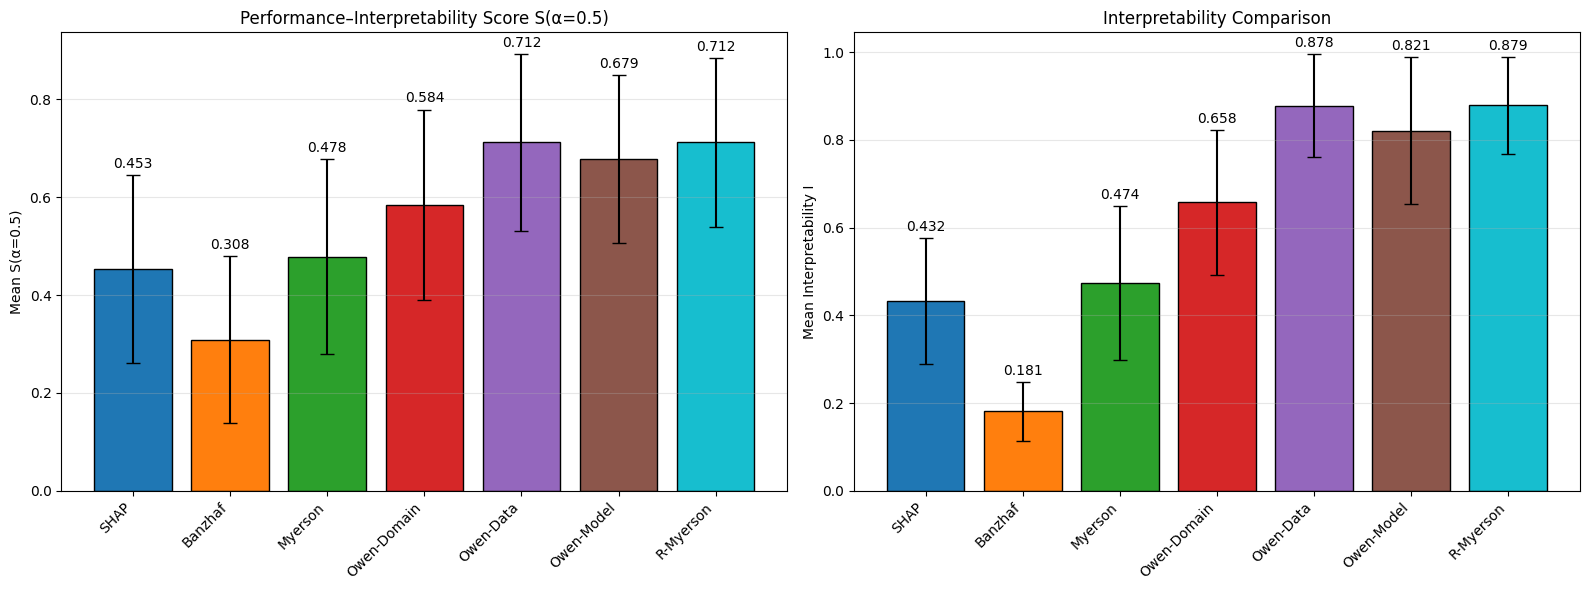

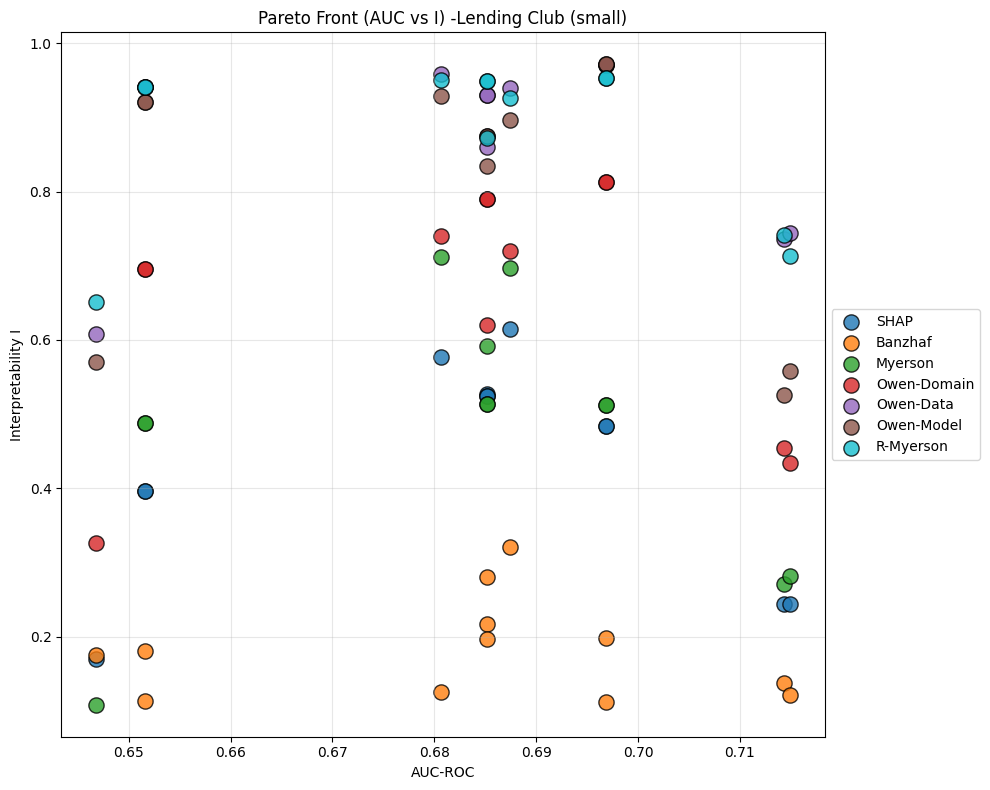

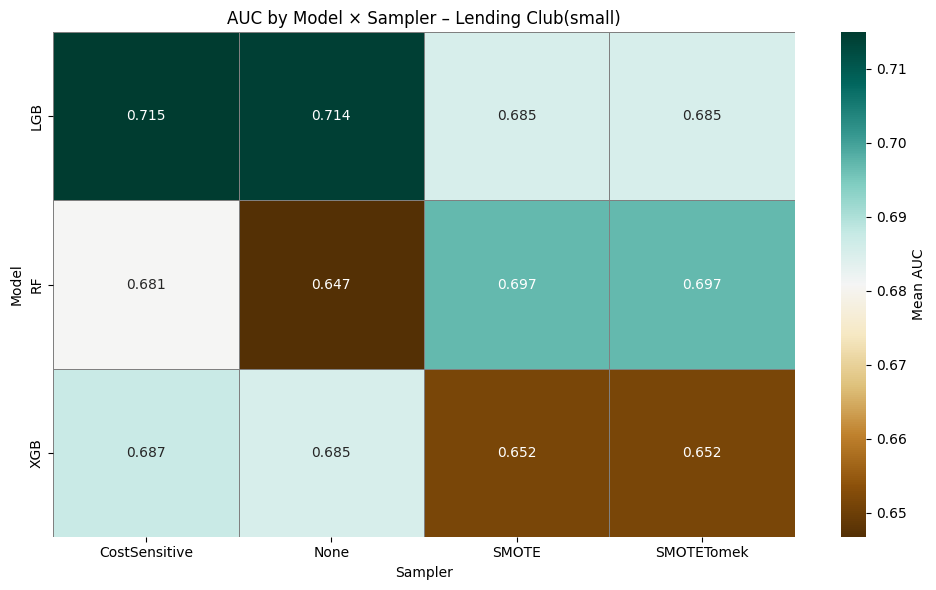

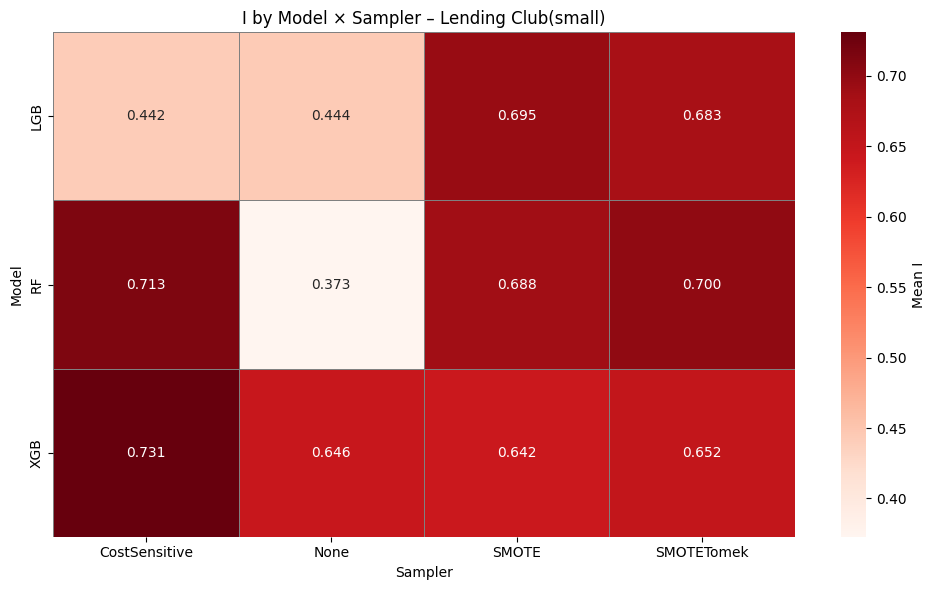

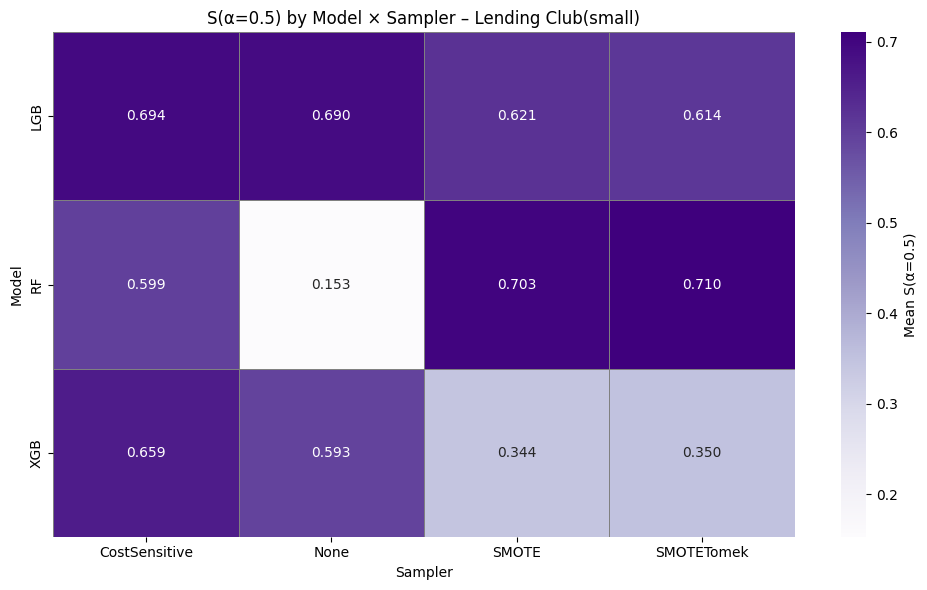

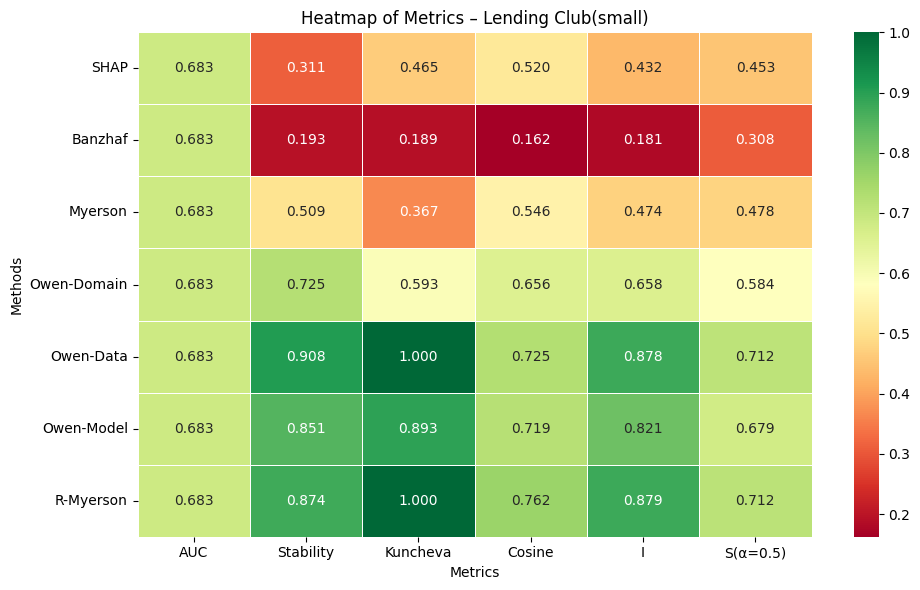

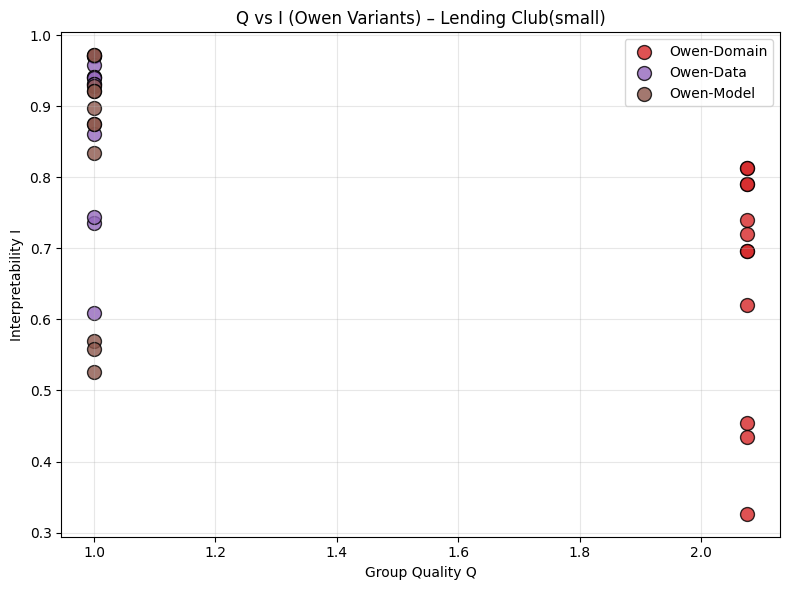

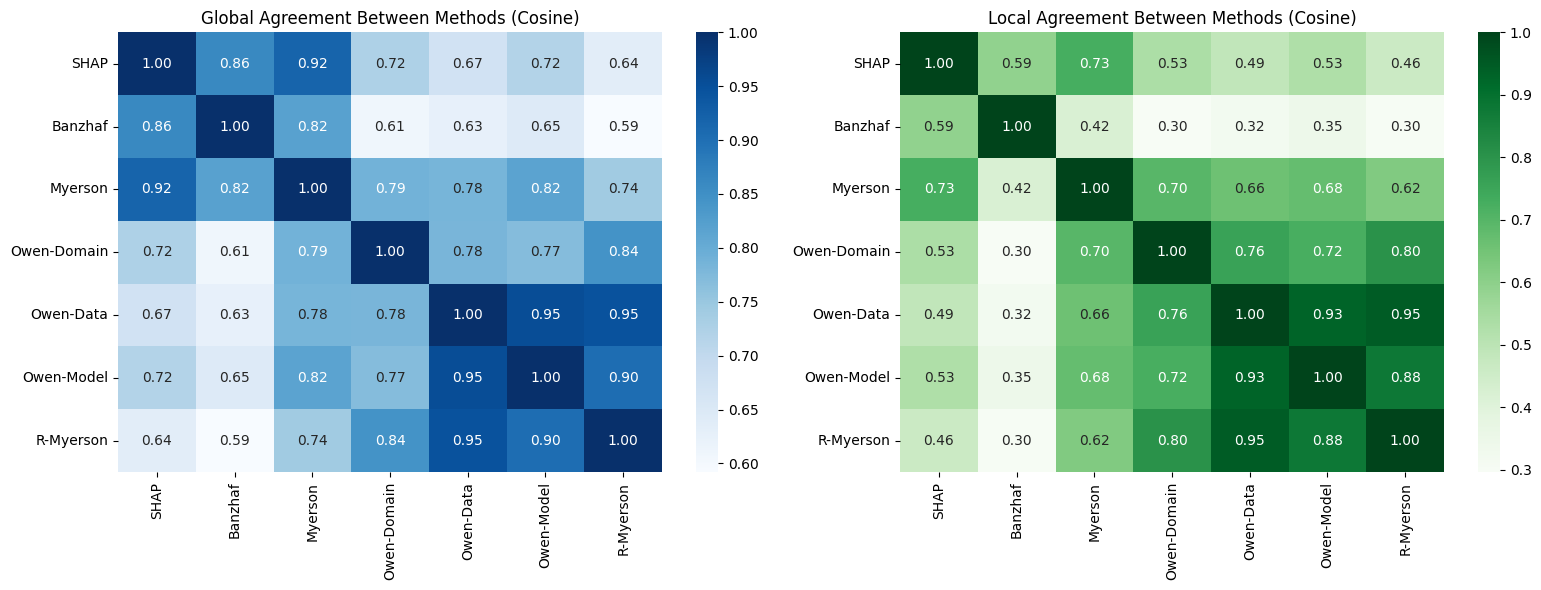


Global Agreement Matrix:
                 SHAP   Banzhaf   Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.000000  0.860235  0.917266     0.724601   0.671596    0.719304   
Banzhaf      0.860235  1.000000  0.819759     0.608753   0.625963    0.645525   
Myerson      0.917266  0.819759  1.000000     0.788540   0.783957    0.815335   
Owen-Domain  0.724601  0.608753  0.788540     1.000000   0.781739    0.769505   
Owen-Data    0.671596  0.625963  0.783957     0.781739   1.000000    0.954631   
Owen-Model   0.719304  0.645525  0.815335     0.769505   0.954631    1.000000   
R-Myerson    0.635266  0.592102  0.741549     0.844963   0.945905    0.902990   

             R-Myerson  
SHAP          0.635266  
Banzhaf       0.592102  
Myerson       0.741549  
Owen-Domain   0.844963  
Owen-Data     0.945905  
Owen-Model    0.902990  
R-Myerson     1.000000  

Local Agreement Matrix:
                 SHAP   Banzhaf   Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.0000

In [2]:
# 9. VISUALIZATIONS
# ============================================================
print("\n" + "="*80)
print("VISUALIZATIONS – Lending Club(small)")
print("="*80)

method_colors = {
    'SHAP':        '#1f77b4',
    'Banzhaf':     '#ff7f0e',
    'Myerson':     '#2ca02c',
    'Owen-Domain': '#d62728',
    'Owen-Data':   '#9467bd',
    'Owen-Model':  '#8c564b',
    'R-Myerson':   '#17becf'
}

model_colors = {
    'RF': '#4C72B0',
    'XGB': '#DD8452',
    'LGB': '#55A868'
}

sampler_colors = {
    'None':          '#5A5A5A',
    'SMOTE':         '#5A3E2B',
    'SMOTETomek':    '#1F3B73',
    'CostSensitive': '#5A2E8A'
}

methods = method_order

# PLOT 1 & 2 – S(α=0.5) and I by method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
S_means = metrics.groupby("Method")["S(α=0.5)"].mean().reindex(methods)
S_stds  = metrics.groupby("Method")["S(α=0.5)"].std().reindex(methods)
bars = ax.bar(
    S_means.index, S_means.values,
    yerr=S_stds.values,
    color=[method_colors[m] for m in S_means.index],
    edgecolor='black', capsize=5
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticklabels(S_means.index, rotation=45, ha='right')
ax.set_ylabel("Mean S(α=0.5)")
ax.set_title("Performance–Interpretability Score S(α=0.5)")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
I_means = metrics.groupby("Method")["I"].mean().reindex(methods)
I_stds  = metrics.groupby("Method")["I"].std().reindex(methods)
bars = ax.bar(
    I_means.index, I_means.values,
    yerr=I_stds.values,
    color=[method_colors[m] for m in I_means.index],
    edgecolor='black', capsize=5
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticklabels(I_means.index, rotation=45, ha='right')
ax.set_ylabel("Mean Interpretability I")
ax.set_title("Interpretability Comparison")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("Lc4_plot1_2_side_by_side.png", dpi=150)
plt.show()

# PLOT 3 – Pareto front (AUC vs I)
plt.figure(figsize=(10, 8))
for method in methods:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['AUC'], sub['I'],
                s=120, label=method,
                color=method_colors[method],
                alpha=0.8, edgecolors='black')
plt.xlabel("AUC-ROC")
plt.ylabel("Interpretability I")
plt.title("Pareto Front (AUC vs I) -Lending Club (small)")
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('Lc4_plot3_pareto.png', dpi=150)
plt.show()

# PLOT 4 – AUC heatmap (Model × Sampler)
plt.figure(figsize=(10, 6))
auc_pivot = metrics.pivot_table(
    values='AUC',
    index='Model',
    columns='Sampler',
    aggfunc='mean'
).fillna(0)
sns.heatmap(
    auc_pivot,
    annot=True,
    fmt=".3f",
    cmap="BrBG",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean AUC'}
)
plt.title("AUC by Model × Sampler – Lending Club(small)")
plt.xlabel("Sampler")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Lc4_plot4_auc_heatmap.png", dpi=150)
plt.show()

# PLOT 5 – I heatmap (Model × Sampler)
plt.figure(figsize=(10, 6))
I_pivot = metrics.pivot_table(
    values='I',
    index='Model',
    columns='Sampler',
    aggfunc='mean'
).fillna(0)
sns.heatmap(
    I_pivot,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean I'}
)
plt.title("I by Model × Sampler – Lending Club(small)")
plt.xlabel("Sampler")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Lc4_I_heatmap.png", dpi=150)
plt.show()

# PLOT 6 – S(α=0.5) heatmap (Model × Sampler)
plt.figure(figsize=(10, 6))
S_pivot = metrics.pivot_table(
    values='S(α=0.5)',
    index='Model',
    columns='Sampler',
    aggfunc='mean'
).fillna(0)
sns.heatmap(
    S_pivot,
    annot=True,
    fmt=".3f",
    cmap="Purples",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean S(α=0.5)'}
)
plt.title("S(α=0.5) by Model × Sampler – Lending Club(small)")
plt.xlabel("Sampler")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("Lc4_S_heatmap.png", dpi=150)
plt.show()

# PLOT 7 – Heatmap of metrics by method
plt.figure(figsize=(10, 6))
heatmap_data = metrics.groupby("Method")[['AUC', 'Stability', 'Kuncheva', 'Cosine', 'I', 'S(α=0.5)']].mean().reindex(methods)
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5)
plt.title("Heatmap of Metrics – Lending Club(small)")
plt.xlabel("Metrics")
plt.ylabel("Methods")
plt.tight_layout()
plt.savefig('Lc4_plot7_heatmap.png', dpi=150)
plt.show()

# PLOT 8 – Q vs I for Owen variants
plt.figure(figsize=(8, 6))
owen_methods = ['Owen-Domain', 'Owen-Data', 'Owen-Model']
for method in owen_methods:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['Q'], sub['I'],
                s=100, label=method,
                color=method_colors[method],
                alpha=0.8, edgecolors='black')
plt.xlabel("Group Quality Q")
plt.ylabel("Interpretability I")
plt.title("Q vs I (Owen Variants) – Lending Club(small)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Lc4_plot8_q_vs_i.png', dpi=150)
plt.show()

# ============================================================
# 10. GLOBAL & LOCAL AGREEMENT (COSINE)
# ============================================================
def plot_global_local_agreement(all_explanations, methods):
    method_names = methods
    M = len(method_names)

    # GLOBAL
    mean_vectors = []
    for method in method_names:
        all_runs = []
        for (mname, sname), method_dict in all_explanations.items():
            all_runs.extend(method_dict[method])
        vec = np.mean([np.abs(e).mean(axis=0) for e in all_runs], axis=0)
        mean_vectors.append(vec)

    G = np.zeros((M, M))
    for i in range(M):
        for j in range(M):
            G[i, j] = 1 - cosine(mean_vectors[i], mean_vectors[j])

    # LOCAL
    L = np.zeros((M, M))
    all_runs = [method_dict for (_, _), method_dict in all_explanations.items()]
    for i, mi in enumerate(method_names):
        for j, mj in enumerate(method_names):
            sims = []
            for run in all_runs:
                Ei_list = run[mi]
                Ej_list = run[mj]
                for Ei, Ej in zip(Ei_list, Ej_list):
                    for vi, vj in zip(Ei, Ej):
                        sims.append(1 - cosine(np.abs(vi), np.abs(vj)))
            L[i, j] = np.mean(sims)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(
        G, annot=True, cmap="Blues",
        xticklabels=method_names, yticklabels=method_names,
        fmt=".2f", ax=axes[0]
    )
    axes[0].set_title("Global Agreement Between Methods (Cosine)")

    sns.heatmap(
        L, annot=True, cmap="Greens",
        xticklabels=method_names, yticklabels=method_names,
        fmt=".2f", ax=axes[1]
    )
    axes[1].set_title("Local Agreement Between Methods (Cosine)")

    plt.tight_layout()
    plt.savefig("Lc4_global_local_agreement.png", dpi=150)
    plt.show()

    print("\nGlobal Agreement Matrix:")
    print(pd.DataFrame(G, index=method_names, columns=method_names))
    print("\nLocal Agreement Matrix:")
    print(pd.DataFrame(L, index=method_names, columns=method_names))

plot_global_local_agreement(all_explanations, methods)


In [3]:
# ============================================================
# 11. STATISTICAL ANALYSIS (FRIEDMAN, NEMENYI, WILCOXON, CORR)
# ============================================================
!pip install pingouin
from scipy.spatial.distance import cosine
from scipy import stats
import scikit_posthocs as sp
import pingouin as pg
print("\n==================== STATISTICAL ANALYSIS – Lending Club(small)====================\n")

results_full = metrics.copy()
alpha = 0.05

def tick(p):
    return "✓" if p < alpha else "✗"

def effect_label(delta):
    d_abs = abs(delta)
    if d_abs < 0.147:
        return "negligible"
    elif d_abs < 0.33:
        return "small"
    elif d_abs < 0.474:
        return "medium"
    else:
        return "large"

def cliffs_delta(x, y):
    x = np.array(x)
    y = np.array(y)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    n1 = len(x)
    n2 = len(y)
    if n1 == 0 or n2 == 0:
        return np.nan
    diffs = x.reshape(-1, 1) - y.reshape(1, -1)
    n_greater = np.sum(diffs > 0)
    n_less = np.sum(diffs < 0)
    return (n_greater - n_less) / (n1 * n2)

pivot_T = results_full.pivot_table(
    values='S(α=0.5)',
    index=['Model', 'Sampler'],
    columns='Method'
)

complete_methods = pivot_T.dropna(axis=1).columns.tolist()
print("Methods included:", complete_methods, "\n")

# 1. Friedman
print("=== Friedman Test ===")
fried_stat, fried_p = stats.friedmanchisquare(
    *[pivot_T[m].values for m in complete_methods]
)
print(f"χ²={fried_stat:.4f}, p={fried_p:.6f} {tick(fried_p)}\n")

# 2. Nemenyi
if fried_p < alpha:
    print("=== Nemenyi Post-hoc ===")
    nemenyi_p = sp.posthoc_nemenyi_friedman(pivot_T[complete_methods].values)
    nemenyi_p.index = complete_methods
    nemenyi_p.columns = complete_methods
    print(nemenyi_p)
    nemenyi_p.to_csv("Lc66_nemenyi_results.csv")
else:
    print("Friedman not significant → skipping Nemenyi.\n")

# 3. Wilcoxon + Cliff's delta
print("\n=== Wilcoxon + Cliff's Delta ===")
rows = []
for i in range(len(complete_methods)):
    for j in range(i + 1, len(complete_methods)):
        m1, m2 = complete_methods[i], complete_methods[j]
        x = pivot_T[m1].values
        y = pivot_T[m2].values
        stat, p = stats.wilcoxon(x, y)
        delta = cliffs_delta(x, y)
        rows.append({
            'Method1': m1,
            'Method2': m2,
            'Wilcoxon_stat': stat,
            'p_value': p,
            'Significant': tick(p),
            "Cliff's_delta": delta,
            'Effect_size': effect_label(delta)
        })

wilcoxon_df = pd.DataFrame(rows)
print(wilcoxon_df)
wilcoxon_df.to_csv("Lc66_wilcoxon_cliffs_results.csv", index=False)

# 4. Correlation AUC vs I
print("\n=== Correlation AUC vs I ===")
rho_s, p_s = stats.spearmanr(results_full['AUC'], results_full['I'])
tau_k, p_k = stats.kendalltau(results_full['AUC'], results_full['I'])

print(f"Spearman ρ={rho_s:.3f}, p={p_s:.6f} {tick(p_s)}")
print(f"Kendall τ={tau_k:.3f}, p={p_k:.6f} {tick(p_k)}")

pd.DataFrame([{
    'Spearman_rho': rho_s,
    'Spearman_p': p_s,
    'Kendall_tau': tau_k,
    'Kendall_p': p_k
}]).to_csv("Lc66_auc_I_correlation.csv", index=False)

print("\n✓ Statistical analysis complete.\n")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.3 MB/s eta 0:00:00

==================== STATISTICAL ANALYSIS – Lending Club(small)====================

Methods included: ['Banzhaf', 'Myerson', 'Owen-Data', 'Owen-Domain', 'Owen-Model', 'R-Myerson', 'SHAP'] 

=== Friedman Test ===
χ²=66.4643, p=0.000000 ✓

=== Nemenyi Post-hoc ===
                  Banzhaf   Myerson     Owen-Data  Owen-Domain  Owen-Model  \
Banzhaf      1.000000e+00  0.615492  1.719956e-07     0.022343    0.000047   
Myerson      6.154925e-01  1.000000  9.527716e-04     0.737844    0.040096   
Owen-Data    1.719956e-07  0.000953  1.000000e+00     0.141329    0.944909   
Owen-Domain  2.234285e-02  0.737844  1.413291e-01     1.000000    0.737844   
Owen-Model   4.735404e-05  0.040096  9.449086e-01     0.737844    1.000000   
R-Myerson    5.518844e-08  0.0


SHAP — Top 3 features for LC 4.01%:
            Feature  Contribution
         revol_util        1.0718
                dti        0.8528
int_rate_times_term        0.7000

Banzhaf — Top 3 features for LC 4.01%:
            Feature  Contribution
                dti        0.2295
     loan_to_income        0.2154
int_rate_times_term        0.2100

Myerson — Top 3 features for LC 4.01%:
            Feature  Contribution
         revol_util        1.0718
                dti        0.4204
int_rate_times_term        0.3612

Owen-Domain — Top 3 features for LC 4.01%:
         Feature  Contribution
       revol_bal        0.5403
      revol_util        0.5403
total_rev_hi_lim       -0.1090

Owen-Data — Top 3 features for LC 4.01%:
            Feature  Contribution
  credit_age_months        -0.106
        issue_month        -0.106
int_rate_times_term         0.106

Owen-Model — Top 3 features for LC 4.01%:
            Feature  Contribution
  credit_age_months       -0.1639
        issue_mont

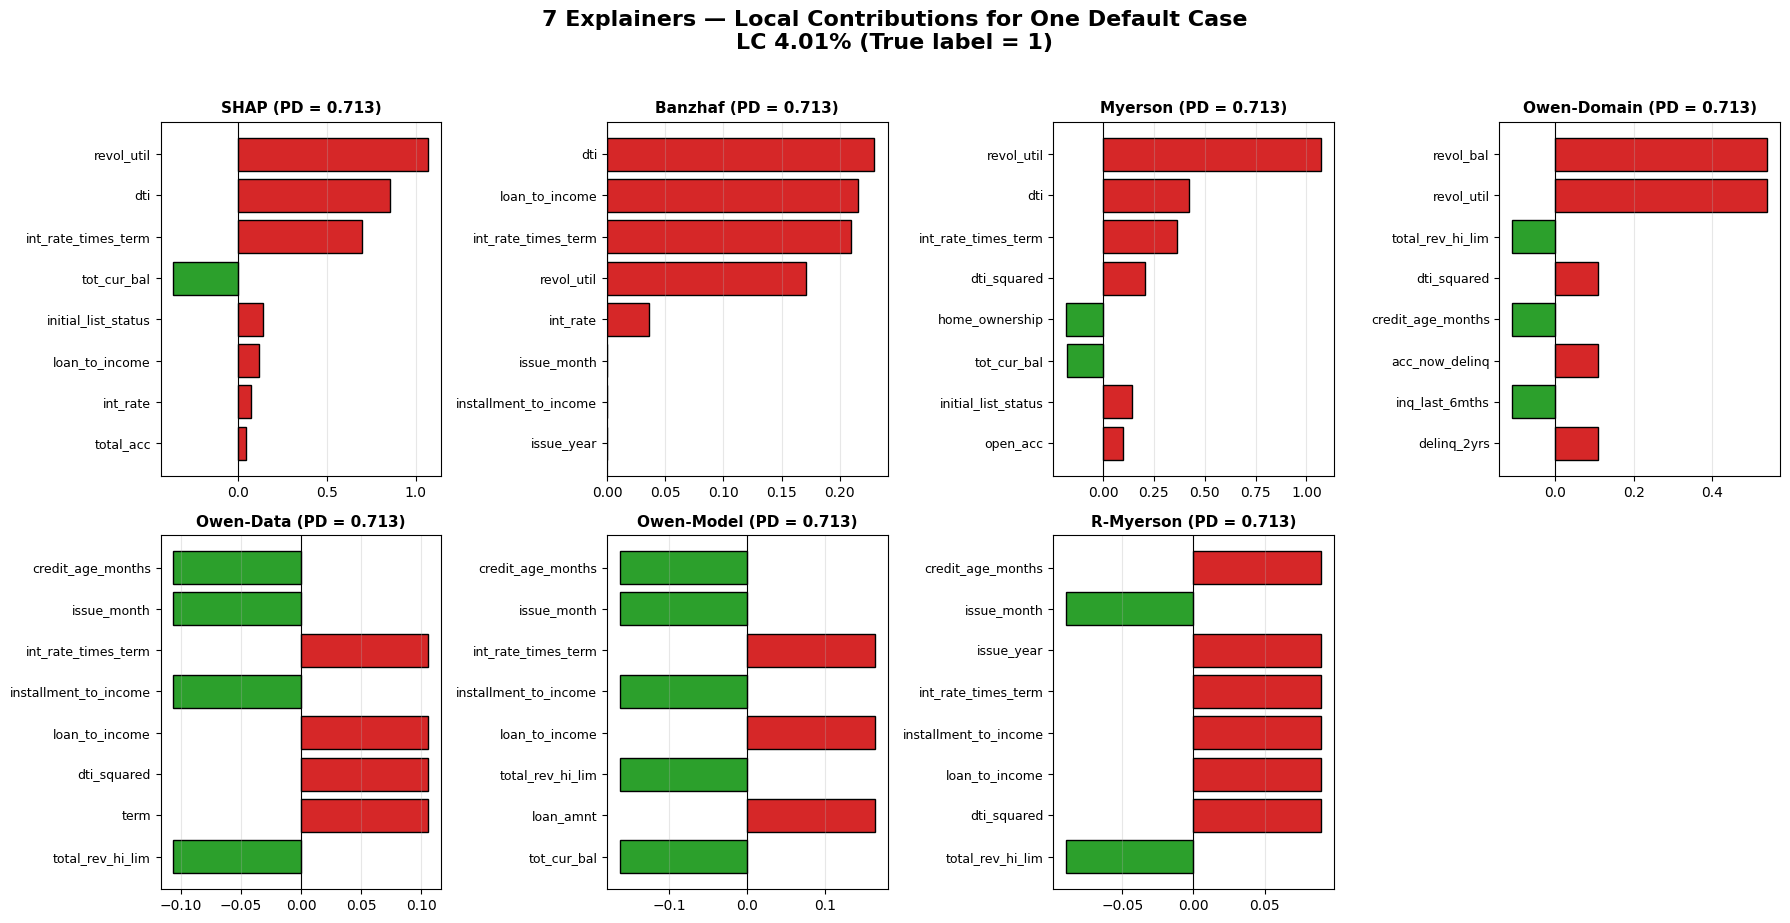


✅ Displayed compact 7-explainers chart + Top-3 tables for LC 4.01%



In [4]:
def plot_7_explainers_top3_default_case(pipe, X_te, y_te, feature_names,
                                        domain_groups, data_groups, model_groups, G_myerson,
                                        dataset_name="Dataset", top_k=8):
    """Compact figure: 7 small bar charts + table of Top-3 features for ONE default case"""

    # Pick first default case
    default_idx = np.where(y_te == 1)[0]
    if len(default_idx) == 0:
        print(f"No default case in {dataset_name}")
        return
    idx = default_idx[0]
    X_inst = X_te.iloc[[idx]]
    proba = pipe.predict_proba(X_inst)[0, 1]

    # Compute all 7 explanations
    shap_inst       = get_shap_values(pipe, X_inst)[0]
    banzhaf_inst    = compute_banzhaf(pipe, X_inst, n_samples=2, max_instances=2)[0]
    myerson_inst, _, _ = compute_myerson(pipe, X_inst, G_myerson)
    myerson_inst    = myerson_inst[0]

    phi_shap = shap_inst
    owen_dom_inst   = owen_from_phi(phi_shap, domain_groups)
    owen_data_inst  = owen_from_phi(phi_shap, data_groups)
    owen_model_inst = owen_from_phi(phi_shap, model_groups)
    r_myerson_inst  = adaptive_owen_myerson(myerson_inst)

    explanations = {
        'SHAP': shap_inst,
        'Banzhaf': banzhaf_inst,
        'Myerson': myerson_inst,
        'Owen-Domain': owen_dom_inst,
        'Owen-Data': owen_data_inst,
        'Owen-Model': owen_model_inst,
        'R-Myerson': r_myerson_inst
    }

    # Create figure with 7 small subplots
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()
    method_order = list(explanations.keys())

    for i, method in enumerate(method_order):
        vals = explanations[method]
        abs_vals = np.abs(vals)
        top_idx = np.argsort(abs_vals)[-top_k:][::-1]

        feats = [feature_names[j].split('__')[-1] for j in top_idx]
        contribs = vals[top_idx]

        colors = ['#d62728' if c > 0 else '#2ca02c' for c in contribs]

        ax = axes[i]
        ax.barh(range(top_k), contribs, color=colors, edgecolor='black')
        ax.set_yticks(range(top_k))
        ax.set_yticklabels(feats, fontsize=9)
        ax.set_title(f'{method} (PD = {proba:.3f})', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        ax.axvline(0, color='black', lw=0.8)

        # Small table of Top-3 features (printed below the chart)
        top3_idx = top_idx[:3]
        top3_feats = [feature_names[j].split('__')[-1] for j in top3_idx]
        top3_vals = vals[top3_idx].round(4)
        table_data = pd.DataFrame({'Feature': top3_feats, 'Contribution': top3_vals})
        print(f"\n{method} — Top 3 features for {dataset_name}:")
        print(table_data.to_string(index=False))

    # Hide empty subplots
    for j in range(7, 8):
        axes[j].set_visible(False)

    fig.suptitle(f'7 Explainers — Local Contributions for One Default Case\n{dataset_name} (True label = 1)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n✅ Displayed compact 7-explainers chart + Top-3 tables for {dataset_name}\n")

plot_7_explainers_top3_default_case(pipe, X_te, y_te, feature_names,
                                    domain_groups, data_groups, model_groups, G_myerson,
                                    dataset_name="LC 4.01%")